# Feature Mask Scores & Political Label Correlation

Given:
- **Token scores** (per image grid cell) from the probe
- **Feature masks** (SAM3 segmentations per extracted feature)
- **Political labels** from the LLM response

Merge all feature masks per image (logical OR) into a combined mask, compute
the mean probe score inside the combined mask, then check correlation
between the combined-mask scores and the model-generated political label.

Labels: LEAN_DEM, NEUTRAL_DEM, NEUTRAL, NEUTRAL_REP, LEAN_REP
with scores -0.5, -0.25, 0.0, 0.25, 0.5.

In [12]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = Path("/project/jevans/tzhang3/dotty-project/linear-political-llm")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [13]:
MODELS = ["qwen3_vl", "gemma4"]
PROBES = [
    "combined_ideology_headwise_linear",
    "combined_ideology_layerwise_linear",
    "combined_ideology_layerwise_rfm",
    "textual_ideology_headwise_linear",
    "textual_ideology_layerwise_linear",
    "textual_ideology_layerwise_rfm",
]

LABEL_TO_SCORE = {
    "LEAN_DEM": -0.5,
    "NEUTRAL_DEM": -0.25,
    "NEUTRAL": 0.0,
    "NEUTRAL_REP": 0.25,
    "LEAN_REP": 0.5,
}
ALL_LABELS = list(LABEL_TO_SCORE.keys())
LABEL_TO_SCORE

{'LEAN_DEM': -0.5,
 'NEUTRAL_DEM': -0.25,
 'NEUTRAL': 0.0,
 'NEUTRAL_REP': 0.25,
 'LEAN_REP': 0.5}

In [14]:
def build_image_lookup(model):
    """Build record_id -> image_path lookup from token scoring CSV."""
    import pandas as pd
    csv_path = ROOT / "results" / "token_scoring" / model / "easyportrait" / f"prompt_token_fg_bg_stats_combined_ideology_headwise_linear.csv"
    if not csv_path.exists():
        return {}
    df = pd.read_csv(csv_path, usecols=["record_id", "image_path"])
    return {str(row["record_id"]): str(ROOT / row["image_path"]) for _, row in df.iterrows()}

# Pre-build image lookups
IMAGE_LOOKUPS = {m: build_image_lookup(m) for m in MODELS}
for m, lu in IMAGE_LOOKUPS.items():
    print(f"  {m}: {len(lu)} image path entries")


def compute_combined_mask_score(row, token_scores, all_masks):
    """
    Merge all feature masks for this record (logical OR), resize to the
    token grid, then compute the mean token score inside the combined mask.
    Returns (mask_score, non_mask_score, coverage, n_found).
    """
    rid = row["record_id"]
    scores = token_scores.get(rid)
    if scores is None:
        return None, None, None, 0

    grid_h = int(row.get("grid_h", 0))
    grid_w = int(row.get("grid_w", 0))
    if grid_h <= 0 or grid_w <= 0:
        return None, None, None, 0

    expected = grid_h * grid_w
    if len(scores) > expected:
        scores = scores[:expected]
    elif len(scores) < expected:
        scores = np.concatenate([scores, np.zeros(expected - len(scores), dtype=scores.dtype)])
    scores_2d = scores.reshape(grid_h, grid_w)

    features = row.get("extracted_features", None)
    if isinstance(features, str):
        try:
            features = json.loads(features)
        except Exception:
            features = [features]
    if not features or features == ["None"]:
        return None, None, None, 0

    combined = None
    n_found = 0
    for fname in features:
        mask_key = f"{rid}/{fname}"
        mask = all_masks.get(mask_key)
        if mask is None:
            continue
        n_found += 1
        from PIL import Image as PILImage
        resized = np.array(
            PILImage.fromarray((mask * 255).astype(np.uint8))
            .resize((grid_w, grid_h), PILImage.BILINEAR)
        ).astype(np.float32) / 255.0
        if combined is None:
            combined = resized
        else:
            combined = np.maximum(combined, resized)

    if combined is None or combined.sum() <= 0:
        return None, None, None, n_found

    weight_sum = combined.sum()
    mask_score = (scores_2d * combined).sum() / weight_sum
    coverage = weight_sum / (grid_h * grid_w)

    non_mask = 1.0 - combined
    non_mask_weight = non_mask.sum()
    if non_mask_weight > 0:
        non_mask_score = (scores_2d * non_mask).sum() / non_mask_weight
    else:
        non_mask_score = float("nan")

    return mask_score, non_mask_score, coverage, n_found

  qwen3_vl: 20000 image path entries
  gemma4: 20000 image path entries


In [15]:
def load_data(model, probe):
    """Load all data for a model x probe combination."""
    base = ROOT / "results" / "token_scoring" / model / "easyportrait"

    # Image token scores npz
    image_npz = np.load(base / f"prompt_image_token_scores_{probe}.npz")
    token_scores = {rid: image_npz[rid] for rid in image_npz.files}
    image_npz.close()

    # All token scores npz
    all_npz = np.load(base / f"prompt_all_token_scores_{probe}.npz")
    all_token_scores = {rid: all_npz[rid] for rid in all_npz.files}
    all_npz.close()

    # CSV metadata (grid info, image stats)
    csv_path = base / f"prompt_token_stats_{probe}.csv"
    df = pd.read_csv(csv_path)
    df["record_id"] = df["record_id"].astype(str)

    # JSONL (labels, features, response)
    jsonl_path = ROOT / "results" / "prompt_generation" / model / "easyportrait_1000samples_max512tok_features.jsonl"
    records = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    pg_df = pd.DataFrame(records)
    pg_df["record_id"] = pg_df["record_id"].astype(str)

    # SAM3 feature masks
    masks_path = ROOT / "results" / "prompt_generation" / model / "easyportrait_1000samples_max512tok_features_sam3_masks.npz"
    if masks_path.exists():
        masks_npz = np.load(masks_path)
        all_masks = {k: masks_npz[k] for k in masks_npz.files}
        masks_npz.close()
    else:
        all_masks = {}

    # Merge
    merge_cols = ["record_id", "extracted_label", "political_score", "political_confidence", "extracted_features", "response"]
    merged = df.merge(pg_df[merge_cols], on="record_id", how="inner")
    merged = merged[merged["record_id"].isin(token_scores.keys())]
    merged = merged[merged["extracted_label"].isin(ALL_LABELS)]

    return token_scores, all_token_scores, merged, all_masks

In [16]:
def compute_metrics(model, probe):
    """Compute all metrics for a model x probe combination."""
    try:
        token_scores, all_token_scores, merged, all_masks = load_data(model, probe)
    except Exception as e:
        return {"model": model, "probe": probe, "_error": str(e)}

    # --- Combined mask scores ---
    mask_rows = []
    for _, row in merged.iterrows():
        mask_score, non_mask_score, coverage, n_found = compute_combined_mask_score(row, token_scores, all_masks)
        if mask_score is None or np.isnan(mask_score):
            continue
        mask_rows.append({
            "record_id": row["record_id"],
            "combined_mask_score": mask_score,
            "non_mask_score": non_mask_score,
            "political_score": LABEL_TO_SCORE.get(row["extracted_label"], 0.0),
        })
    mask_df = pd.DataFrame(mask_rows)

    # --- Last token scores ---
    last_rows = []
    for _, row in merged.iterrows():
        rid = row["record_id"]
        scores = all_token_scores.get(rid)
        if scores is None or len(scores) == 0:
            continue
        label = row["extracted_label"]
        if pd.isna(label) or label not in LABEL_TO_SCORE:
            continue
        last_rows.append({
            "record_id": rid,
            "last_token_score": scores[-1],
            "political_score": LABEL_TO_SCORE[label],
        })
    last_df = pd.DataFrame(last_rows)

    # --- Image mean vs label ---
    merged["political_score_num"] = merged["extracted_label"].map(LABEL_TO_SCORE)
    img_valid = merged[["image_mean", "political_score_num"]].dropna()

    # --- Correlations ---
    results = {"model": model, "probe": probe, "n_records": len(merged)}

    if len(mask_df) > 2:
        r_mask, _ = stats.pearsonr(mask_df["combined_mask_score"], mask_df["political_score"])
        r_nonmask, _ = stats.pearsonr(mask_df["non_mask_score"].dropna(),
                                       mask_df.loc[mask_df["non_mask_score"].notna(), "political_score"])
    else:
        r_mask, r_nonmask = np.nan, np.nan

    if len(img_valid) > 2:
        r_image_mean, _ = stats.pearsonr(img_valid["image_mean"], img_valid["political_score_num"])
    else:
        r_image_mean = np.nan

    if len(last_df) > 2:
        r_last, _ = stats.pearsonr(last_df["last_token_score"], last_df["political_score"])
    else:
        r_last = np.nan

    results.update({
        "mask_n": len(mask_df),
        "combined_mask": r_mask,
        "non_mask": r_nonmask,
        "last_token_n": len(last_df),
        "last_token": r_last,
        "image_mean": r_image_mean,
    })

    return results

In [17]:
from itertools import product

all_results = []
for model, probe in product(MODELS, PROBES):
    print(f"Processing {model} / {probe} ...")
    res = compute_metrics(model, probe)
    all_results.append(res)
    print(f"  n={res.get('n_records')}, mask_r={res.get('combined_mask'):.4f}, last_r={res.get('last_token'):.4f}, img_r={res.get('image_mean'):.4f}")

results_df = pd.DataFrame(all_results)
print(f"\nDone. {len(results_df)} rows.")

Processing qwen3_vl / combined_ideology_headwise_linear ...
  n=999, mask_r=0.2954, last_r=0.2557, img_r=0.3249
Processing qwen3_vl / combined_ideology_layerwise_linear ...
  n=999, mask_r=0.3419, last_r=0.3422, img_r=0.3688
Processing qwen3_vl / combined_ideology_layerwise_rfm ...
  n=999, mask_r=0.2899, last_r=0.2150, img_r=0.3219
Processing qwen3_vl / textual_ideology_headwise_linear ...
  n=999, mask_r=0.2846, last_r=0.3028, img_r=0.3053
Processing qwen3_vl / textual_ideology_layerwise_linear ...
  n=999, mask_r=0.2937, last_r=0.2733, img_r=0.3401
Processing qwen3_vl / textual_ideology_layerwise_rfm ...
  n=999, mask_r=0.3181, last_r=0.3058, img_r=0.3428
Processing gemma4 / combined_ideology_headwise_linear ...
  n=903, mask_r=0.6176, last_r=0.5335, img_r=0.6183
Processing gemma4 / combined_ideology_layerwise_linear ...
  n=903, mask_r=0.4426, last_r=0.1030, img_r=0.4934
Processing gemma4 / combined_ideology_layerwise_rfm ...
  n=903, mask_r=0.5228, last_r=0.3433, img_r=0.5822
Proc

## Summary: Pearson r by Model x Probe

In [18]:
display_cols = ["model", "probe", "n_records", "combined_mask", "non_mask", "last_token", "image_mean"]
table = results_df[display_cols].copy()

def highlight_best(s):
    """Highlight the cell with the max absolute value in each numeric column."""
    if s.dtype == float:
        is_best = s.abs() == s.abs().max()
        return ["background-color: #c8e6c9" if v else "" for v in is_best]
    return ["" for _ in s]

styled = (table
    .style
    .format({"combined_mask": "{:.4f}", "non_mask": "{:.4f}", "last_token": "{:.4f}", "image_mean": "{:.4f}"})
    .apply(highlight_best, subset=["combined_mask", "non_mask", "last_token", "image_mean"])
    .set_caption("Pearson r between score and political label (negative = more Dem)")
)
styled

,model,probe,n_records,combined_mask,non_mask,last_token,image_mean
0,qwen3_vl,combined_ideology_headwise_linear,999,0.2954,0.2911,0.2557,0.3249
1,qwen3_vl,combined_ideology_layerwise_linear,999,0.3419,0.3199,0.3422,0.3688
2,qwen3_vl,combined_ideology_layerwise_rfm,999,0.2899,0.2560,0.2150,0.3219
3,qwen3_vl,textual_ideology_headwise_linear,999,0.2846,0.2701,0.3028,0.3053
4,qwen3_vl,textual_ideology_layerwise_linear,999,0.2937,0.2918,0.2733,0.3401
5,qwen3_vl,textual_ideology_layerwise_rfm,999,0.3181,0.2797,0.3058,0.3428
6,gemma4,combined_ideology_headwise_linear,903,0.6176,0.5968,0.5335,0.6183
7,gemma4,combined_ideology_layerwise_linear,903,0.4426,0.4394,0.1030,0.4934
8,gemma4,combined_ideology_layerwise_rfm,903,0.5228,0.5464,0.3433,0.5822
9,gemma4,textual_ideology_headwise_linear,903,0.4892,0.5282,0.1541,0.5492


## Detail: Combined Mask Score Distribution (single model/probe)

In [19]:
DETAIL_MODEL = "qwen3_vl"
DETAIL_PROBE = "combined_ideology_headwise_linear"

token_scores, all_token_scores, merged, all_masks = load_data(DETAIL_MODEL, DETAIL_PROBE)
print(f"{DETAIL_MODEL} / {DETAIL_PROBE}: {len(merged)} records")
merged.head(3)

qwen3_vl / combined_ideology_headwise_linear: 999 records


,record_id,record_name,image_path,image_h,image_w,grid_h,grid_w,num_image_tokens,expected_image_tokens,image_token_mismatch,...,all_mean,all_median,all_min,all_max,all_std,extracted_label,political_score,political_confidence,extracted_features,response
0,easyportrait_000013,01128996-0bd2-42be-a75f-cf46a7a28373.jpg,results/token_scoring/qwen3_vl/easyportrait/_r...,800,600,25,19,475,475,0,...,0.292558,0.237745,-0.575825,1.727874,0.380790,NEUTRAL,0.0,1,"[plain gray t-shirt, neutral expression, no vi...",NEUTRAL\n\nJustification: The man in the photo...
1,easyportrait_000018,0153049f-fb50-4656-85fa-2905fbea28a8.jpg,results/token_scoring/qwen3_vl/easyportrait/_r...,800,600,25,19,475,475,0,...,0.132268,0.067854,-0.733582,1.318797,0.360038,LEAN_DEM,-0.5,1,"[wide eyes, open mouth, light green t-shirt, g...",LEAN_DEM\n\nJustification: The person in the p...
2,easyportrait_000037,023f82c6-b256-4b05-98e5-0a6c7b98e305.jpg,results/token_scoring/qwen3_vl/easyportrait/_r...,800,600,25,19,475,475,0,...,0.116469,0.049199,-0.957544,1.738749,0.375477,LEAN_DEM,-0.5,1,"[t-shirt, tie-dye, floral wallpaper, home sett...",LEAN_DEM\n\nJustification:\nThe man is wearing...


In [20]:
rows_list = []
for _, row in merged.iterrows():
    mask_score, non_mask_score, coverage, n_found = compute_combined_mask_score(row, token_scores, all_masks)
    if mask_score is None or np.isnan(mask_score):
        continue
    rows_list.append({
        "record_id": row["record_id"],
        "combined_mask_score": mask_score,
        "non_mask_score": non_mask_score,
        "mask_coverage": coverage,
        "n_features_found": n_found,
        "extracted_label": row["extracted_label"],
        "political_score": LABEL_TO_SCORE.get(row["extracted_label"], 0.0),
        "image_mean": row["image_mean"],
    })

record_df = pd.DataFrame(rows_list)
print(f"Records with combined mask score: {len(record_df)}")
print(f"Mean features found per record: {record_df['n_features_found'].mean():.1f}")
record_df.head()

Records with combined mask score: 986
Mean features found per record: 2.9


,record_id,combined_mask_score,non_mask_score,mask_coverage,n_features_found,extracted_label,political_score,image_mean
0,easyportrait_000013,0.319021,0.276951,0.270448,2,NEUTRAL,0.0,0.288328
1,easyportrait_000018,0.058125,0.119702,0.266510,4,LEAN_DEM,-0.5,0.103291
2,easyportrait_000037,0.083709,-0.007853,0.999018,4,LEAN_DEM,-0.5,0.083619
3,easyportrait_000055,0.125429,0.218383,0.499872,4,NEUTRAL,0.0,0.171918
4,easyportrait_000070,0.337849,0.340494,0.041478,2,LEAN_DEM,-0.5,0.340384


/scratch/local/jobs/50073581/ipykernel_2968980/1875576606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


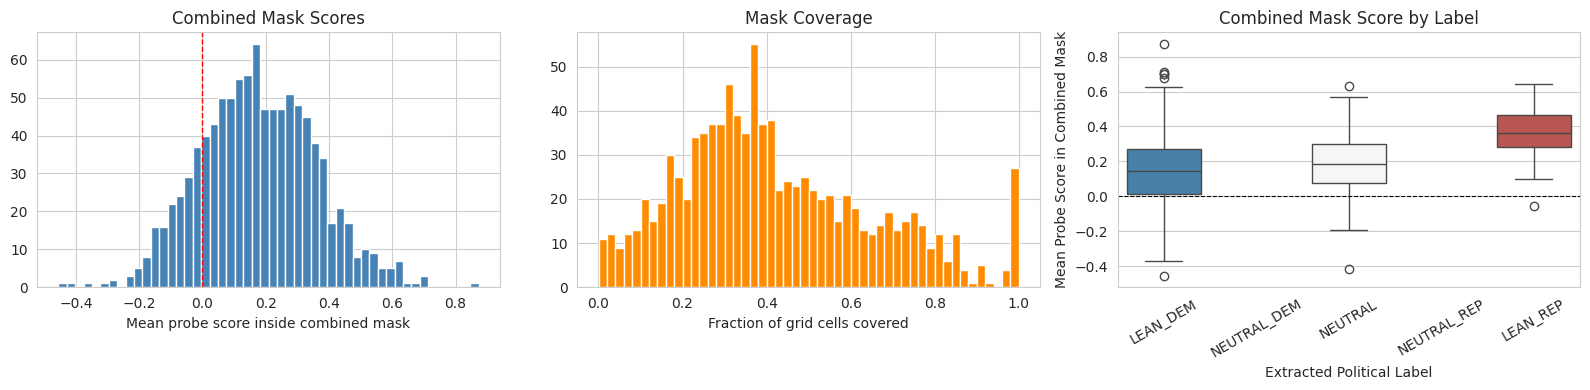

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(record_df["combined_mask_score"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Combined Mask Scores")
axes[0].set_xlabel("Mean probe score inside combined mask")

axes[1].hist(record_df["mask_coverage"].dropna(), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Mask Coverage")
axes[1].set_xlabel("Fraction of grid cells covered")

label_order = ["LEAN_DEM", "NEUTRAL_DEM", "NEUTRAL", "NEUTRAL_REP", "LEAN_REP"]
plot_df = record_df[record_df["extracted_label"].isin(label_order)].copy()
plot_df["extracted_label"] = pd.Categorical(plot_df["extracted_label"], categories=label_order, ordered=True)
sns.boxplot(
    data=plot_df, x="extracted_label", y="combined_mask_score",
    palette="RdBu_r", order=label_order, ax=axes[2],
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Combined Mask Score by Label")
axes[2].set_xlabel("Extracted Political Label")
axes[2].set_ylabel("Mean Probe Score in Combined Mask")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

/scratch/local/jobs/50073581/ipykernel_2968980/57344838.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


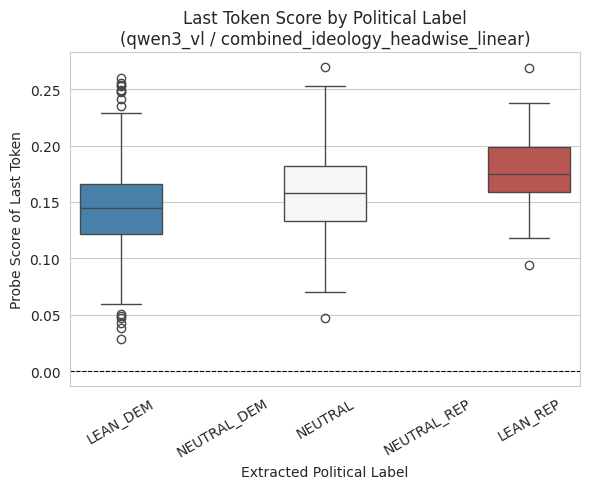

In [22]:
# Last token scores for this model/probe
last_rows = []
for _, row in merged.iterrows():
    rid = row["record_id"]
    scores = all_token_scores.get(rid)
    if scores is None or len(scores) == 0:
        continue
    label = row["extracted_label"]
    if pd.isna(label) or label not in LABEL_TO_SCORE:
        continue
    last_rows.append({
        "record_id": rid,
        "last_token_score": scores[-1],
        "extracted_label": label,
    })
last_df = pd.DataFrame(last_rows)

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=last_df, x="extracted_label", y="last_token_score",
    palette="RdBu_r", order=label_order, ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title(f"Last Token Score by Political Label\n({DETAIL_MODEL} / {DETAIL_PROBE})")
ax.set_xlabel("Extracted Political Label")
ax.set_ylabel("Probe Score of Last Token")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Per-Feature Analysis: Generic Feature Name vs Political Score

For each individual feature mask (not combined), compute the mean token score
inside the mask. Then group by the feature's **last word** (generic name),
and report the highest-scoring and most-variable features.

In [23]:
from collections import defaultdict

feature_patterns = {}  # generic_name -> list of (record_id, feature_full, image_token_score)

for _, row in merged.iterrows():
    rid = row["record_id"]
    scores_arr = token_scores.get(rid)
    if scores_arr is None:
        continue
    grid_h = int(row.get("grid_h", 0))
    grid_w = int(row.get("grid_w", 0))
    if grid_h <= 0 or grid_w <= 0:
        continue

    expected = grid_h * grid_w
    if len(scores_arr) > expected:
        scores_arr = scores_arr[:expected]
    elif len(scores_arr) < expected:
        scores_arr = np.concatenate([scores_arr, np.zeros(expected - len(scores_arr), dtype=scores_arr.dtype)])
    scores_2d = scores_arr.reshape(grid_h, grid_w)

    features = row.get("extracted_features", None)
    if isinstance(features, str):
        try:
            features = json.loads(features)
        except Exception:
            features = [features]
    if not features or features == ["None"]:
        continue

    for fname in features:
        mask_key = f"{rid}/{fname}"
        mask = all_masks.get(mask_key)
        if mask is None:
            continue

        from PIL import Image as PILImage
        resized = np.array(
            PILImage.fromarray((mask * 255).astype(np.uint8))
            .resize((grid_w, grid_h), PILImage.BILINEAR)
        ).astype(np.float32) / 255.0

        if resized.sum() <= 0:
            continue

        feat_score = (scores_2d * resized).sum() / resized.sum()

        # Last word as generic name
        words = fname.strip().split()
        generic = words[-1].rstrip(",.;:!?") if words else fname

        feature_patterns.setdefault(generic, []).append(feat_score)

print(f"Unique generic feature names: {len(feature_patterns)}")
print(f"Total feature-mask instances: {sum(len(v) for v in feature_patterns.values())}")

Unique generic feature names: 425
Total feature-mask instances: 2900


In [24]:
feat_stats = []
for name, scores in feature_patterns.items():
    if len(scores) < 5:  # min instances for reliable stats
        continue
    arr = np.array(scores)
    feat_stats.append({
        "feature": name,
        "n": len(scores),
        "mean": arr.mean(),
        "std": arr.std(),
        "median": np.median(arr),
        "min": arr.min(),
        "max": arr.max(),
    })

feat_df = pd.DataFrame(feat_stats).sort_values("mean", ascending=False)
print(f"Features with >=5 instances: {len(feat_df)}")

# Top 15 by highest mean score (most Republican)
print("\n=== Top 15: Highest mean probe score (most Republican) ===")
feat_df.head(15)[["feature", "n", "mean", "std", "median"]]

Features with >=5 instances: 96

=== Top 15: Highest mean probe score (most Republican) ===


,feature,n,mean,std,median
54,brows,6,0.502682,0.241805,0.536118
50,head,19,0.488124,0.147647,0.477824
57,stripes,9,0.450796,0.182527,0.508396
40,ceiling,8,0.446904,0.104248,0.468529
32,beard,32,0.412640,0.198274,0.349009
62,clock,10,0.404380,0.145786,0.366720
48,cap,6,0.402810,0.218670,0.500275
65,lighting,6,0.393554,0.159834,0.446605
73,cabinets,6,0.388217,0.195189,0.371978
27,blanket,5,0.364736,0.113355,0.406627


In [25]:
# Top 15 by highest variance (std)
print("=== Top 15: Most variable probe score (highest std) ===")
feat_df.sort_values("std", ascending=False).head(15)[["feature", "n", "mean", "std", "min", "max"]]

=== Top 15: Most variable probe score (highest std) ===


,feature,n,mean,std,min,max
41,painting,7,0.044104,0.372323,-0.678770,0.382618
38,face,5,0.261202,0.338108,-0.261296,0.637539
39,haircut,26,0.312762,0.335637,-0.734659,0.785676
12,graphic,27,-0.202581,0.328674,-0.915397,0.537976
17,decor,5,0.136309,0.316182,-0.182290,0.567686
31,hair,125,0.223226,0.292319,-0.580194,0.935077
56,furniture,9,0.306775,0.283678,-0.040760,0.858655
35,design,24,-0.072917,0.268556,-0.540132,0.714087
82,bangs,6,-0.092468,0.267641,-0.631369,0.213480
76,door,9,0.254485,0.263306,-0.359068,0.592263


In [26]:
# Bottom 15 by lowest mean score (most Democratic)
# Bottom 15: Lowest mean probe score (most Democratic)
feat_df.tail(15)[["feature", "n", "mean", "std", "median"]]

,feature,n,mean,std,median
72,pendant,10,0.008621,0.245062,0.008309
66,earbuds,8,-0.011208,0.096896,-0.013726
84,jewelry,12,-0.066185,0.132350,-0.059871
35,design,24,-0.072917,0.268556,-0.086020
90,piercings,5,-0.079107,0.104652,-0.120363
15,tee,11,-0.089214,0.194049,-0.029476
82,bangs,6,-0.092468,0.267641,0.006754
74,trees,11,-0.097896,0.155038,-0.065195
85,window,5,-0.105348,0.221169,-0.187980
25,out,8,-0.118845,0.033574,-0.115809


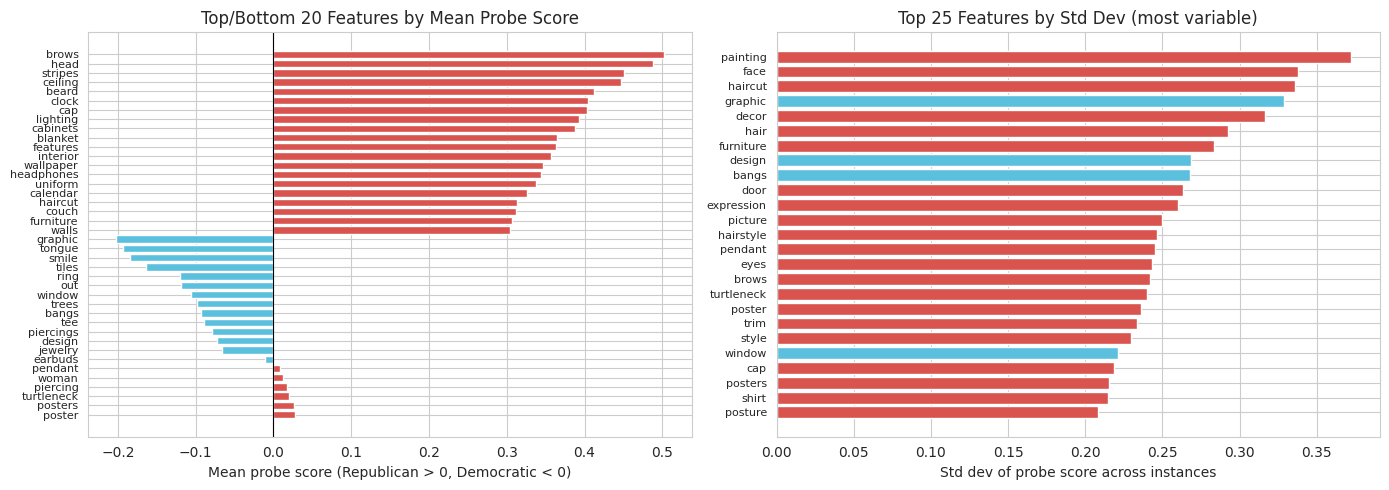

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top/bottom 20 features by mean score
top_n = 20
top_feats = feat_df.nlargest(top_n, "mean")
bot_feats = feat_df.nsmallest(top_n, "mean")
plot_feats = pd.concat([top_feats, bot_feats]).drop_duplicates(subset="feature")

axes[0].barh(range(len(plot_feats)), plot_feats["mean"],
             color=["#d9534f" if v > 0 else "#5bc0de" for v in plot_feats["mean"]])
axes[0].set_yticks(range(len(plot_feats)))
axes[0].set_yticklabels(plot_feats["feature"], fontsize=8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Top/Bottom {top_n} Features by Mean Probe Score")
axes[0].set_xlabel("Mean probe score (Republican > 0, Democratic < 0)")
axes[0].invert_yaxis()

# Top 25 most variable
var_feats = feat_df.nlargest(25, "std")
colors = ["#d9534f" if v > 0 else "#5bc0de" for v in var_feats["mean"]]
axes[1].barh(range(len(var_feats)), var_feats["std"], color=colors)
axes[1].set_yticks(range(len(var_feats)))
axes[1].set_yticklabels(var_feats["feature"], fontsize=8)
axes[1].set_title("Top 25 Features by Std Dev (most variable)")
axes[1].set_xlabel("Std dev of probe score across instances")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
# Full table sorted by |mean|
feat_df["abs_mean"] = feat_df["mean"].abs()
feat_df.sort_values("abs_mean", ascending=False).head(50)[["feature", "n", "mean", "std", "median"]]

,feature,n,mean,std,median
54,brows,6,0.502682,0.241805,0.536118
50,head,19,0.488124,0.147647,0.477824
57,stripes,9,0.450796,0.182527,0.508396
40,ceiling,8,0.446904,0.104248,0.468529
32,beard,32,0.412640,0.198274,0.349009
62,clock,10,0.404380,0.145786,0.366720
48,cap,6,0.402810,0.218670,0.500275
65,lighting,6,0.393554,0.159834,0.446605
73,cabinets,6,0.388217,0.195189,0.371978
27,blanket,5,0.364736,0.113355,0.406627
